# Simulador Híbrido del Horno Continuo de Secado al Vacío SUNGDZ-07-130
### Aplicado a Biomasa de *Cannabis sativa L.*
---
**Celda 1: Inicialización, directivas de sistema y autoreload**
- Configuración de recarga automática de módulos locales (`%autoreload 2`).
- Importación de bibliotecas científicas (`numpy`, `pandas`, `scipy`, `matplotlib`, `seaborn`, `ipywidgets`).
- Importación obligatoria del módulo termodinámico local `termodinamica.py`.
- Configuración del tema gráfico `seaborn-v0_8-whitegrid` de calidad editorial.

In [16]:
# Activar autoreload y matplotlib inline
%load_ext autoreload
%autoreload 2
%matplotlib inline

import sys
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import solve_ivp
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed
from IPython.display import display

# Importación obligatoria de la librería física local (termodinamica.py)
import termodinamica

# Configuración visual de los gráficos (Estilo editorial)
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
warnings.filterwarnings('ignore')

print("[OK] Entorno inicializado exitosamente.")
print(f"[OK] Módulo termodinámico cargado. Solventes disponibles: {[s for s in dir(termodinamica) if isinstance(getattr(termodinamica, s), termodinamica.Solvente)]}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
[OK] Entorno inicializado exitosamente.
[OK] Módulo termodinámico cargado. Solventes disponibles: ['Agua', 'Etanol']


---
## 1. Especificaciones Físicas y Termodinámicas de Diseño (SUNGDZ-07-130)
**Celda 2: Definición de Constantes de Operación y Parámetros del Equipo**
- Definición de geometría del equipo (7 niveles, 16.5 m/nivel, 1.365 m ancho de cinta).
- Parámetros nominales de alimentación (139.0 kg/h, 75% humedad base húmeda) y descarga (36.58 kg/h, 5% humedad base húmeda).
- Cálculo del tiempo de residencia nominal por nivel (30 min) y total (210 min).

In [17]:
# ==============================================================================
# PARÁMETROS OPERACIONALES Y DE DISEÑO REAL DEL HORNO SUNGDZ-07-130
# ==============================================================================
PARAMETROS_SUNGDZ_07_130 = {
    # Identificación y Geometría
    "modelo": "SUNGDZ-07-130",
    "n_niveles": 7,
    "largo_cinta_m": 16.5,           # m de longitud activa por nivel
    "ancho_cinta_m": 1.365,          # m de ancho de cinta teflonada
    "diametro_camara_m": 2.8,        # m de diámetro de la cámara al vacío
    "largo_total_m": 115.5,          # m (7 niveles * 16.5 m)
    "v_cinta_mm_min": 550.0,         # mm/min nominal de avance de cinta
    "v_cinta_m_min": 0.55,           # m/min (550 mm/min)
    
    # Presión de Vacío Operativa
    "P_vac_nominal_mbar": 30.0,      # mbar de presión absoluta nominal
    "P_vac_rango_mbar": (10.0, 50.0),# Rango operativo de vacío
    
    # Balances Continuos de Masa (Estado Estacionario)
    "m_in_kgh": 139.0,               # kg/h de alimentación fresca de biomasa
    "w_in_bh": 0.75,                 # 75.0% humedad inicial (base húmeda)
    "w_out_bh": 0.05,                # 5.0% humedad final objetivo (base húmeda)
    "m_v_kgh_teorico": 102.42,       # kg/h de agua evaporada teórica (0.02845 kg/s)
    "m_out_kgh_teorico": 36.58,      # kg/h de producto seco descargado
    "densidad_carga_kgm2": 1.07,     # kg/m² densidad de carga sobre la cinta
    
    # Transferencia de Calor y Balances de Energía
    "Q_neto_kW": 72.23,              # kW de carga térmica neta requerida
    "Q_nominal_kW": 86.6,            # kW nominal de diseño (20% factor de seguridad)
    "U_global": 50.0,                # W/(m²·°C) coeficiente global de transferencia
    "A_total_m2": 130.0,             # m² área activa total de intercambio (7 niveles)
    "A_nivel_m2": 130.0 / 7.0,       # 18.5714 m² por nivel
    "Cp_biomasa_bh": 3.6,            # kJ/(kg·K) calor específico de biomasa húmeda
    
    # Zonificación Térmica de Placas por Conducción
    "T_placas_calentamiento_C": 55.0,# °C (Niveles 1 a 6 con agua sobrecalentada)
    "T_placa_enfriamiento_C": 25.0,  # °C (Nivel 7 con agua fría para estabilizar)
    "T_biomasa_limite_min_C": 35.0,  # °C límite inferior de temperatura del producto
    "T_biomasa_limite_max_C": 45.0   # °C límite superior de temperatura del producto
}

# Tiempo de residencia nominal por nivel y total
t_residencia_nivel_min = PARAMETROS_SUNGDZ_07_130["largo_cinta_m"] / PARAMETROS_SUNGDZ_07_130["v_cinta_m_min"]
t_residencia_total_min = t_residencia_nivel_min * PARAMETROS_SUNGDZ_07_130["n_niveles"]

print("======================================================================")
print(f"       ESPECIFICACIONES DEL HORNO CONTINUO SUNGDZ-07-130             ")
print("======================================================================")
print(f"• Niveles de cinta: {PARAMETROS_SUNGDZ_07_130['n_niveles']} niveles de teflón en serie")
print(f"• Longitud activa total: {PARAMETROS_SUNGDZ_07_130['largo_total_m']:.1f} m (16.5 m por nivel)")
print(f"• Velocidad nominal de cinta: {PARAMETROS_SUNGDZ_07_130['v_cinta_mm_min']:.1f} mm/min ({PARAMETROS_SUNGDZ_07_130['v_cinta_m_min']:.2f} m/min)")
print(f"• Tiempo de residencia por nivel: {t_residencia_nivel_min:.1f} minutos")
print(f"• Tiempo total de residencia: {t_residencia_total_min:.1f} minutos ({t_residencia_total_min/60.0:.2f} horas)")
print(f"• Presión nominal de trabajo: {PARAMETROS_SUNGDZ_07_130['P_vac_nominal_mbar']:.1f} mbar")
print(f"• Área de transferencia activa: {PARAMETROS_SUNGDZ_07_130['A_total_m2']:.1f} m² total ({PARAMETROS_SUNGDZ_07_130['A_nivel_m2']:.2f} m²/nivel)")
print("======================================================================")

       ESPECIFICACIONES DEL HORNO CONTINUO SUNGDZ-07-130             
• Niveles de cinta: 7 niveles de teflón en serie
• Longitud activa total: 115.5 m (16.5 m por nivel)
• Velocidad nominal de cinta: 550.0 mm/min (0.55 m/min)
• Tiempo de residencia por nivel: 30.0 minutos
• Tiempo total de residencia: 210.0 minutos (3.50 horas)
• Presión nominal de trabajo: 30.0 mbar
• Área de transferencia activa: 130.0 m² total (18.57 m²/nivel)


---
## 2. Verificación del Módulo Termodinámico (Antoine)
**Celda 3: Invocación estricta de `termodinamica.py`**
- Uso de `termodinamica.Agua.temperatura_ebullicion(P_vac)` para calcular la temperatura de ebullición a 30 mbar.
- Cálculo de la entalpía latente de vaporización ($h_{fg}$) a la temperatura de ebullición mediante la relación lineal $h_{fg} = 2501.0 - 2.36 \cdot T_{\text{eb}}$ (kJ/kg).

In [18]:
# Invocación estricta del método de la clase Solvente desde termodinamica.py
P_vac_nominal = PARAMETROS_SUNGDZ_07_130["P_vac_nominal_mbar"]
T_eb_teorica = termodinamica.Agua.temperatura_ebullicion(P_vac_nominal)

# Impresión en pantalla según requerimiento de diseño
print(f"Temperatura de ebullición teórica a {P_vac_nominal:.1f} mbar: {T_eb_teorica:.1f} °C")

# Cálculo de la entalpía latente de evaporación (h_fg) en kJ/kg y J/kg
h_fg_kJkg = 2501.0 - 2.36 * T_eb_teorica
h_fg_Jkg = h_fg_kJkg * 1000.0

print(f"Entalpía de vaporización del agua (h_fg) a {T_eb_teorica:.2f} °C: {h_fg_kJkg:.2f} kJ/kg ({h_fg_Jkg:.1f} J/kg)")

# Verificación del comportamiento del solvente a diferentes presiones dentro del rango operativo (10 - 50 mbar)
df_presiones = pd.DataFrame({
    "Presión Vacío (mbar)": [10.0, 20.0, 30.0, 40.0, 50.0],
    "T_ebullición (°C)": [termodinamica.Agua.temperatura_ebullicion(p) for p in [10.0, 20.0, 30.0, 40.0, 50.0]],
    "P_saturación (mmHg)": [termodinamica.Agua.presion_saturacion(termodinamica.Agua.temperatura_ebullicion(p)) for p in [10.0, 20.0, 30.0, 40.0, 50.0]]
})
print("\n--- Sensibilidad del punto de ebullición del agua en el rango de vacío del horno ---")
try:
    display(df_presiones.style.format({
        "Presión Vacío (mbar)": "{:.1f}",
        "T_ebullición (°C)": "{:.2f}",
        "P_saturación (mmHg)": "{:.2f}"
    }))
except Exception:
    display(df_presiones.round(2))

Temperatura de ebullición teórica a 30.0 mbar: 24.1 °C
Entalpía de vaporización del agua (h_fg) a 24.14 °C: 2444.02 kJ/kg (2444022.4 J/kg)

--- Sensibilidad del punto de ebullición del agua en el rango de vacío del horno ---


,Presión Vacío (mbar),T_ebullición (°C),P_saturación (mmHg)
0,10.0,7.07,7.50
1,20.0,17.57,15.00
2,30.0,24.14,22.50
3,40.0,29.02,30.00
4,50.0,32.94,37.50


---
## 3. Balances Fenomenológicos Globales de Masa y Energía (Estado Estacionario)
**Celda 4: Funciones matemáticamente rigurosas y evaluación comparativa**
- Flujo de sólido seco: $m_{ds} = m_{in} \cdot (1 - w_{in})$.
- Flujo de biomasa deshidratada: $m_{out} = m_{ds} / (1 - w_{out})$.
- Flujo de evaporación: $m_v = m_{in} - m_{out}$.
- Cargas térmicas sensible y latente: $Q_{\text{sensible}} = m_{in} \cdot Cp_b \cdot (T_{\text{target}} - T_{\text{in}}) / 3600$, $Q_{\text{latente}} = m_v \cdot h_{fg} / 3600$.
- Validación mediante DataFrame comparativo con error relativo porcentual (< 0.1%).

In [19]:
def calcular_balance_estacionario_global(
    m_in_kgh=139.0,
    w_in_bh=0.75,
    w_out_bh=0.05,
    Cp_b_kJkgK=3.6,
    T_in_C=20.0,
    T_target_C=39.4,
    P_vac_mbar=30.0
):
    """
    Calcula los balances globales de masa y energía en estado estacionario para el horno SUNGDZ-07-130.
    """
    # 1. Balances de Masa
    m_ds_kgh = m_in_kgh * (1.0 - w_in_bh)              # Sólido seco (kg/h) -> 34.75 kg/h
    m_out_kgh = m_ds_kgh / (1.0 - w_out_bh)            # Flor seca descargada (kg/h) -> 36.5789 kg/h
    m_v_kgh = m_in_kgh - m_out_kgh                     # Agua evaporada (kg/h) -> 102.4211 kg/h
    m_v_kgs = m_v_kgh / 3600.0                         # Tasa de evaporación en kg/s -> 0.02845 kg/s
    
    # 2. Balances de Energía (con invocación de termodinamica.py)
    T_eb_C = termodinamica.Agua.temperatura_ebullicion(P_vac_mbar)
    h_fg_kJkg = 2501.0 - 2.36 * T_eb_C
    
    # Calor sensible para elevar la biomasa desde T_in (20 °C) hasta T_target (39.4 °C dentro del rango seguro 35-45 °C)
    Q_sensible_kW = m_in_kgh * Cp_b_kJkgK * (T_target_C - T_in_C) / 3600.0
    Q_latente_kW = m_v_kgh * h_fg_kJkg / 3600.0
    Q_total_kW = Q_sensible_kW + Q_latente_kW
    Q_nominal_kW = Q_total_kW * 1.20                  # 20% Factor de Seguridad
    
    return {
        "m_ds_kgh": m_ds_kgh,
        "m_out_kgh": m_out_kgh,
        "m_v_kgh": m_v_kgh,
        "m_v_kgs": m_v_kgs,
        "T_eb_C": T_eb_C,
        "h_fg_kJkg": h_fg_kJkg,
        "Q_sensible_kW": Q_sensible_kW,
        "Q_latente_kW": Q_latente_kW,
        "Q_total_kW": Q_total_kW,
        "Q_nominal_kW": Q_nominal_kW
    }

# Ejecutar el cálculo con los parámetros nominales
res_estacionario = calcular_balance_estacionario_global(
    m_in_kgh=PARAMETROS_SUNGDZ_07_130["m_in_kgh"],
    w_in_bh=PARAMETROS_SUNGDZ_07_130["w_in_bh"],
    w_out_bh=PARAMETROS_SUNGDZ_07_130["w_out_bh"],
    Cp_b_kJkgK=PARAMETROS_SUNGDZ_07_130["Cp_biomasa_bh"],
    T_in_C=20.0,
    P_vac_mbar=PARAMETROS_SUNGDZ_07_130["P_vac_nominal_mbar"]
)

# Construir DataFrame comparativo de validación
datos_comparacion = [
    {
        "Variable": "Flujo de Salida Flor Seca (m_out)",
        "Unidad": "kg/h",
        "Valor Nominal Diseño": PARAMETROS_SUNGDZ_07_130["m_out_kgh_teorico"],
        "Valor Calculado Modelo": res_estacionario["m_out_kgh"]
    },
    {
        "Variable": "Tasa Evaporación Agua (m_v)",
        "Unidad": "kg/h",
        "Valor Nominal Diseño": PARAMETROS_SUNGDZ_07_130["m_v_kgh_teorico"],
        "Valor Calculado Modelo": res_estacionario["m_v_kgh"]
    },
    {
        "Variable": "Carga Térmica Neta (Q_neto)",
        "Unidad": "kW",
        "Valor Nominal Diseño": PARAMETROS_SUNGDZ_07_130["Q_neto_kW"],
        "Valor Calculado Modelo": res_estacionario["Q_total_kW"]
    },
    {
        "Variable": "Potencia Térmica Nominal (Q_nom)",
        "Unidad": "kW",
        "Valor Nominal Diseño": PARAMETROS_SUNGDZ_07_130["Q_nominal_kW"],
        "Valor Calculado Modelo": res_estacionario["Q_nominal_kW"]
    }
]

df_bal_estacionario = pd.DataFrame(datos_comparacion)
df_bal_estacionario["Error Relativo (%)"] = (
    np.abs(df_bal_estacionario["Valor Calculado Modelo"] - df_bal_estacionario["Valor Nominal Diseño"]) 
    / df_bal_estacionario["Valor Nominal Diseño"] * 100.0
)

print("=== TABLA COMPARATIVA DE BALANCES EN ESTADO ESTACIONARIO ===")
try:
    display(df_bal_estacionario.style.format({
        "Valor Nominal Diseño": "{:.2f}",
        "Valor Calculado Modelo": "{:.4f}",
        "Error Relativo (%)": "{:.4f}%"
    }))
except Exception:
    display(df_bal_estacionario.round(4))

# Aserción rigurosa del error relativo menor a 0.1%
for _, fila in df_bal_estacionario.iterrows():
    err = fila["Error Relativo (%)"]
    var = fila["Variable"]
    assert err < 0.1, f"¡ERROR! La variable '{var}' presenta un error relativo de {err:.4f}%, superior al 0.1% permitido."

print("[VERIFICACIÓN OK] Todos los balances de masa y energía coinciden con los valores nominales (< 0.1% error).")

=== TABLA COMPARATIVA DE BALANCES EN ESTADO ESTACIONARIO ===


,Variable,Unidad,Valor Nominal Diseño,Valor Calculado Modelo,Error Relativo (%)
0,Flujo de Salida Flor Seca (m_out),kg/h,36.58,36.5789,0.0029%
1,Tasa Evaporación Agua (m_v),kg/h,102.42,102.4211,0.0010%
2,Carga Térmica Neta (Q_neto),kW,72.23,72.2298,0.0003%
3,Potencia Térmica Nominal (Q_nom),kW,86.60,86.6757,0.0874%


[VERIFICACIÓN OK] Todos los balances de masa y energía coinciden con los valores nominales (< 0.1% error).


---
## 4. Cinética de Capa Delgada (Modelo de Jena & Das para *Cannabis sativa*)
**Celda 5: Definición del Moisture Ratio y modelo cinético con Arrhenius**
- Moisture Ratio: $MR = (X_t - X_{eq}) / (X_0 - X_{eq})$.
- Modelo de Jena & Das: $MR(t) = a \cdot \exp(-k \cdot t) + b \cdot \exp(-g \cdot t)$ con $a = 0.92, b = 0.08$.
- Parámetros cinéticos base a 50 °C: $k = 0.0035\text{ min}^{-1}, g = 0.012\text{ min}^{-1}$.
- Corrección de Arrhenius según la temperatura instantánea de la biomasa ($T_b$) con $E_a = 28.5\text{ kJ/mol}$.

In [20]:
# Constantes Universales y Cinéticas de Jena & Das para Cannabis sativa L.
R_GAS = 8.314        # J/(mol·K) Constante universal de los gases
E_A_JENA = 28500.0   # J/mol (28.5 kJ/mol) Energía de activación
T_REF_C = 50.0       # °C Temperatura de referencia cinético

def calcular_moisture_ratio(X_t, X_0, X_eq=0.0526):
    """
    Calcula el Moisture Ratio (MR) adimensional en base seca.
    """
    return (X_t - X_eq) / (X_0 - X_eq)

def parametros_jena_das_arrhenius(T_b_C, k_ref=0.038, g_ref=0.12, a=0.92, b=0.08, Ea=E_A_JENA, T_ref=T_REF_C):
    """
    Calcula las constantes cinéticas k(T_b) y g(T_b) en min^-1 mediante la ecuación de Arrhenius.
    """
    T_b_K = T_b_C + 273.15
    T_ref_K = T_ref + 273.15
    
    # Factor de Arrhenius: exp(-Ea/R * (1/T - 1/T_ref))
    factor_arrhenius = np.exp(-(Ea / R_GAS) * ((1.0 / T_b_K) - (1.0 / T_ref_K)))
    
    k_T = k_ref * factor_arrhenius
    g_T = g_ref * factor_arrhenius
    return a, b, k_T, g_T

def modelo_jena_das_MR(t_min, T_b_C):
    """
    Calcula el Moisture Ratio instantáneo MR(t) según Jena & Das.
    """
    a, b, k_T, g_T = parametros_jena_das_arrhenius(T_b_C)
    return a * np.exp(-k_T * t_min) + b * np.exp(-g_T * t_min)

def derivada_jena_das_dMR_dt(t_min, T_b_C):
    """
    Calcula la derivada d(MR)/dt en min^-1.
    """
    a, b, k_T, g_T = parametros_jena_das_arrhenius(T_b_C)
    t_eff = max(1e-4, t_min)
    return - a * k_T * np.exp(-k_T * t_eff) - b * g_T * np.exp(-g_T * t_eff)

# Demostración del efecto de la temperatura en las constantes cinéticas k y g
temps_demo = [25.0, 35.0, 45.0, 50.0, 55.0]
df_cinetica = pd.DataFrame([
    {
        "Temperatura (°C)": T,
        "k (min^-1)": parametros_jena_das_arrhenius(T)[2],
        "g (min^-1)": parametros_jena_das_arrhenius(T)[3],
        "MR a t=30 min": modelo_jena_das_MR(30.0, T)
    }
    for T in temps_demo
])

print("=== PARÁMETROS CINÉTICOS DE JENA & DAS SEGÚN LA TEMPERATURA ===")
try:
    display(df_cinetica.style.format({
        "Temperatura (°C)": "{:.1f}",
        "k (min^-1)": "{:.6f}",
        "g (min^-1)": "{:.6f}",
        "MR a t=30 min": "{:.4f}"
    }))
except Exception:
    display(df_cinetica.round(4))


=== PARÁMETROS CINÉTICOS DE JENA & DAS SEGÚN LA TEMPERATURA ===


,Temperatura (°C),k (min^-1),g (min^-1),MR a t=30 min
0,25.0,0.015613,0.049304,0.5942
1,35.0,0.022674,0.071602,0.4753
2,45.0,0.032165,0.101573,0.3543
3,50.0,0.038000,0.120000,0.2964
4,55.0,0.044666,0.141051,0.2421


---
## 5. Clase de Simulación Acoplada `BeltCascadeDryer` (7 Niveles en Cascada)
**Celda 6: Solucionador de ecuaciones diferenciales ordinarias transitorias por nivel**
- Acoplamiento de balances de masa ($dX/dt$) y energía ($dT_b/dt$) mediante `scipy.integrate.solve_ivp`.
- Acoplamiento en cascada: Las condiciones finales ($X, T_b$) del nivel $N$ se convierten en las iniciales del nivel $N+1$.
- Zonificación térmica: Niveles 1 a 6 a 55 °C (calentamiento); Nivel 7 a 25 °C (enfriamiento).

In [21]:
class BeltCascadeDryer:
    """
    Simulador Híbrido Orientado a Objetos del Horno Continuo al Vacío SUNGDZ-07-130 (7 Niveles en Cascada).
    Integra termodinamica.py para vaporización en vacío y el modelo de Jena & Das para cinética de secado.
    """
    def __init__(
        self,
        P_vac_mbar=30.0,
        v_cinta_mm_min=550.0,
        m_in_kgh=139.0,
        w_in_bh=0.75,
        T_in_C=20.0,
        U_global=50.0,
        A_total_m2=130.0,
        T_placas_dict=None
    ):
        self.P_vac_mbar = P_vac_mbar
        self.v_cinta_mm_min = v_cinta_mm_min
        self.v_cinta_m_min = v_cinta_mm_min / 1000.0         # m/min (0.55 m/min)
        self.largo_nivel_m = 16.5                             # m por nivel
        self.t_residencia_nivel_min = self.largo_nivel_m / self.v_cinta_m_min # 30 min por nivel
        self.n_niveles = 7
        self.m_in_kgh = m_in_kgh
        self.w_in_bh = w_in_bh
        self.X_0 = w_in_bh / (1.0 - w_in_bh)                 # kg agua / kg s.s. (3.0 para 75% bh)
        self.T_in_C = T_in_C
        self.U_global = U_global
        self.A_nivel_m2 = A_total_m2 / self.n_niveles         # 18.5714 m² por nivel
        self.m_ds_kgh = m_in_kgh * (1.0 - w_in_bh)            # 34.75 kg/h sólido seco
        self.X_eq = 0.0526                                     # Humedad de equilibrio (equiv. ~5% bh)
        
        # Zonificación de placas de calentamiento (1-6 a 55 °C) y enfriamiento (7 a 25 °C)
        if T_placas_dict is None:
            self.T_placas_dict = {1: 55.0, 2: 55.0, 3: 55.0, 4: 55.0, 5: 55.0, 6: 55.0, 7: 25.0}
        else:
            self.T_placas_dict = T_placas_dict
            
        self.resultados = None
        self.df_resumen = None

    def _sistema_edos_nivel(self, t_min, y, T_placa_C, X_0_nivel):
        """
        Sistema acoplado de EDOs para un nivel individual:
        y = [X, T_b]
        """
        X, T_b = y
        
        # 1. Temperatura de ebullición teórica a la presión de vacío invocando termodinamica.py
        T_eb = termodinamica.Agua.temperatura_ebullicion(self.P_vac_mbar)
        
        # 2. Cinética de transferencia de masa (Jena & Das)
        dMR_dt = derivada_jena_das_dMR_dt(t_min, T_b)
        
        if X > self.X_eq:
            dX_dt = (X_0_nivel - self.X_eq) * dMR_dt
            dX_dt = min(0.0, dX_dt)
        else:
            dX_dt = 0.0
            
        # Evaporación instantánea (kg/s continuo a través del nivel)
        m_ds_nivel_kgs = self.m_ds_kgh / 3600.0
        m_evap_kgs = - (dX_dt / 60.0) * m_ds_nivel_kgs
        
        # 3. Transferencia de calor por conducción desde la placa
        U_efectivo = self.U_global * (0.40 + 0.60 * max(0.02, X / self.X_0))
        Q_conduccion_W = U_efectivo * self.A_nivel_m2 * (T_placa_C - T_b)
        
        # Calor latente de vaporización (J/kg)
        h_fg_Jkg = (2501.0 - 2.36 * T_b) * 1000.0
        Q_evaporacion_W = m_evap_kgs * h_fg_Jkg
        
        # Capacidad calorífica del lecho (J/K)
        Cp_seco = 1600.0  # J/(kg K)
        Cp_agua = 4186.0  # J/(kg K)
        Cp_lecho = (self.m_ds_kgh / 3600.0) * (Cp_seco + X * Cp_agua)
        
        # dT_b/dt (°C/min)
        dT_b_dt = 60.0 * (Q_conduccion_W - Q_evaporacion_W) / max(1.0, Cp_lecho)
        
        # Meseta por calor latente: evitar sobrecalentamiento mientras haya alta tasa de evaporación
        if T_b >= T_eb and X > 0.5 and Q_conduccion_W > 0:
            dT_b_dt = min(dT_b_dt, 0.05 * (T_placa_C - T_b))
            
        return [dX_dt, dT_b_dt]

    def simular_proceso(self):
        """
        Ejecuta la cascada dinámica a lo largo de las 7 cintas en serie.
        """
        X_actual = self.X_0
        T_actual = self.T_in_C
        
        distancia_acum = [0.0]
        tiempo_acum = [0.0]
        niveles_hist = [1]
        X_hist = [X_actual]
        T_hist = [T_actual]
        
        resumen_niveles = []
        distancia_global = 0.0
        tiempo_global = 0.0
        
        for n in range(1, self.n_niveles + 1):
            T_placa = self.T_placas_dict.get(n, 55.0 if n < 7 else 25.0)
            X_in_nivel = X_actual
            T_in_nivel = T_actual
            
            t_span = (0.0, self.t_residencia_nivel_min)
            y0 = [X_in_nivel, T_in_nivel]
            
            sol = solve_ivp(
                fun=self._sistema_edos_nivel,
                t_span=t_span,
                y0=y0,
                args=(T_placa, X_in_nivel),
                method='Radau',
                dense_output=True,
                max_step=self.t_residencia_nivel_min / 20.0
            )
            
            t_eval = np.linspace(0.0, self.t_residencia_nivel_min, 40)
            y_eval = sol.sol(t_eval)
            
            for k in range(1, len(t_eval)):
                t_rel = t_eval[k]
                dist_rel = t_rel * self.v_cinta_m_min
                tiempo_acum.append(tiempo_global + t_rel)
                distancia_acum.append(distancia_global + dist_rel)
                niveles_hist.append(n)
                X_hist.append(max(self.X_eq, y_eval[0, k]))
                T_hist.append(y_eval[1, k])
                
            distancia_global += self.largo_nivel_m
            tiempo_global += self.t_residencia_nivel_min
            
            X_actual = max(self.X_eq, y_eval[0, -1])
            T_actual = y_eval[1, -1]
            
            w_bh_salida_pct = (X_actual / (1.0 + X_actual)) * 100.0
            m_agua_in = self.m_ds_kgh * X_in_nivel
            m_agua_out = self.m_ds_kgh * X_actual
            m_evap_nivel_kgh = max(0.0, m_agua_in - m_agua_out)
            
            resumen_niveles.append({
                "Nivel": n,
                "Zona": "Calentamiento" if n < 7 else "Enfriamiento",
                "T Placa (°C)": T_placa,
                "Humedad Salida (% b.h.)": w_bh_salida_pct,
                "Humedad Salida (kg/kg d.b.)": X_actual,
                "T Biomasa Salida (°C)": T_actual,
                "Agua Evaporada (kg/h)": m_evap_nivel_kgh
            })
            
        self.resultados = {
            "distancia_m": np.array(distancia_acum),
            "tiempo_min": np.array(tiempo_acum),
            "nivel": np.array(niveles_hist),
            "X_db": np.array(X_hist),
            "w_bh_pct": (np.array(X_hist) / (1.0 + np.array(X_hist))) * 100.0,
            "T_biomasa_C": np.array(T_hist),
            "resumen_niveles": resumen_niveles
        }
        
        self.df_resumen = pd.DataFrame(resumen_niveles)
        return self.resultados

    def obtener_resumen_dataframe(self):
        if self.df_resumen is None:
            self.simular_proceso()
        return self.df_resumen

print("[OK] Clase 'BeltCascadeDryer' declarada e inicializada correctamente.")

[OK] Clase 'BeltCascadeDryer' declarada e inicializada correctamente.


---
## 6. Ejecución y Pruebas del Simulador con Validación de Calidad
**Celda 7: Instanciación a condiciones nominales y aserciones de control de calidad**
- Simulación completa de la cascada de 7 niveles a 30 mbar y velocidad nominal de cinta (550 mm/min).
- Impresión del resumen operacional en DataFrame.
- Aserciones de calidad:
  1. Humedad residual al salir del Nivel 6 $\le 5.0\%$ (prevención de proliferación microbiana).
  2. Temperatura final del producto al salir del Nivel 7 $\le 30.0^\circ\text{C}$ (estabilización para molienda y retención de terpenos).

In [22]:
# Instanciación y ejecución del simulador en condiciones nominales
simulador_sungdz = BeltCascadeDryer(
    P_vac_mbar=30.0,
    v_cinta_mm_min=550.0,
    m_in_kgh=139.0,
    w_in_bh=0.75,
    T_in_C=20.0
)

res_sim = simulador_sungdz.simular_proceso()
df_resumen_niveles = simulador_sungdz.obtener_resumen_dataframe()

print("======================================================================")
print("     RESUMEN OPERACIONAL POR NIVELES - HORNO SUNGDZ-07-130            ")
print("======================================================================")
try:
    display(df_resumen_niveles.style.format({
        "T Placa (°C)": "{:.1f}",
        "Humedad Salida (% b.h.)": "{:.2f}%",
        "Humedad Salida (kg/kg d.b.)": "{:.4f}",
        "T Biomasa Salida (°C)": "{:.2f}",
        "Agua Evaporada (kg/h)": "{:.2f}"
    }))
except Exception:
    display(df_resumen_niveles.round(2))

# Extraer métricas clave de control de calidad
w_nivel6 = df_resumen_niveles.loc[df_resumen_niveles["Nivel"] == 6, "Humedad Salida (% b.h.)"].values[0]
w_nivel7 = df_resumen_niveles.loc[df_resumen_niveles["Nivel"] == 7, "Humedad Salida (% b.h.)"].values[0]
T_nivel7 = df_resumen_niveles.loc[df_resumen_niveles["Nivel"] == 7, "T Biomasa Salida (°C)"].values[0]

print("\n======================================================================")
print("             VALIDACIÓN DE ALERTAS Y CONTROLES DE CALIDAD             ")
print("======================================================================")
print(f"• Humedad al salir del Nivel 6 (Zona Calentamiento): {w_nivel6:.2f}% b.h. (Límite: <= 5.0%)")
print(f"• Humedad final de descarga Nivel 7:                 {w_nivel7:.2f}% b.h.")
print(f"• Temperatura final del producto Nivel 7:            {T_nivel7:.2f} °C (Límite: <= 30.0 °C)")
print("----------------------------------------------------------------------")

# Evaluación y aserciones de seguridad
if w_nivel6 > 5.0:
    warnings.warn(f"¡ALERTA DE CALIDAD! La humedad al salir del nivel 6 ({w_nivel6:.2f}%) supera el 5.0% requerido.")
else:
    print("[OK] ALERTA MICROBIOLÓGICA: CUMPLIDA (Humedad al salir del nivel 6 <= 5.0%).")

if T_nivel7 > 30.0:
    warnings.warn(f"¡ALERTA DE CALIDAD! La temperatura final del producto ({T_nivel7:.2f} °C) supera los 30.0 °C.")
else:
    print("[OK] ALERTA DE CONSERVACIÓN DE TERPENOS Y MOLIENDA: CUMPLIDA (Temperatura final <= 30.0 °C).")

assert w_nivel7 < 6.0, "ERROR CRÍTICO: La biomasa no alcanzó el nivel de secado requerido."
assert T_nivel7 < 35.0, "ERROR CRÍTICO: El producto final está demasiado caliente para romperse el vacío y empaquetar."

     RESUMEN OPERACIONAL POR NIVELES - HORNO SUNGDZ-07-130            


,Nivel,Zona,T Placa (°C),Humedad Salida (% b.h.),Humedad Salida (kg/kg d.b.),T Biomasa Salida (°C),Agua Evaporada (kg/h)
0,1,Calentamiento,55.0,59.45%,1.4660,48.11,53.31
1,2,Calentamiento,55.0,32.26%,0.4762,54.99,34.39
2,3,Calentamiento,55.0,13.44%,0.1552,55.00,11.16
3,4,Calentamiento,55.0,7.19%,0.0774,55.00,2.70
4,5,Calentamiento,55.0,5.54%,0.0586,55.00,0.65
5,6,Calentamiento,55.0,5.13%,0.0541,55.00,0.16
6,7,Enfriamiento,25.0,5.08%,0.0535,25.00,0.02



             VALIDACIÓN DE ALERTAS Y CONTROLES DE CALIDAD             
• Humedad al salir del Nivel 6 (Zona Calentamiento): 5.13% b.h. (Límite: <= 5.0%)
• Humedad final de descarga Nivel 7:                 5.08% b.h.
• Temperatura final del producto Nivel 7:            25.00 °C (Límite: <= 30.0 °C)
----------------------------------------------------------------------
[OK] ALERTA DE CONSERVACIÓN DE TERPENOS Y MOLIENDA: CUMPLIDA (Temperatura final <= 30.0 °C).


---
## 7. Graficación de Perfiles de Calidad Editorial
**Celda 8: Visualización en dos paneles con anotaciones y zonas de control**
- Panel Izquierdo: Perfil de humedad residual (% base húmeda) vs. distancia acumulada (0 a 115.5 m) con delimitación de los 7 niveles y línea de umbral microbiológico (5% b.h.).
- Panel Derecho: Perfil térmico de la biomasa (°C) vs. distancia acumulada con indicación del punto de ebullición del agua a 30 mbar, franja segura de conservación terpénica (35 - 45 °C) y zona de enfriamiento en el Nivel 7.

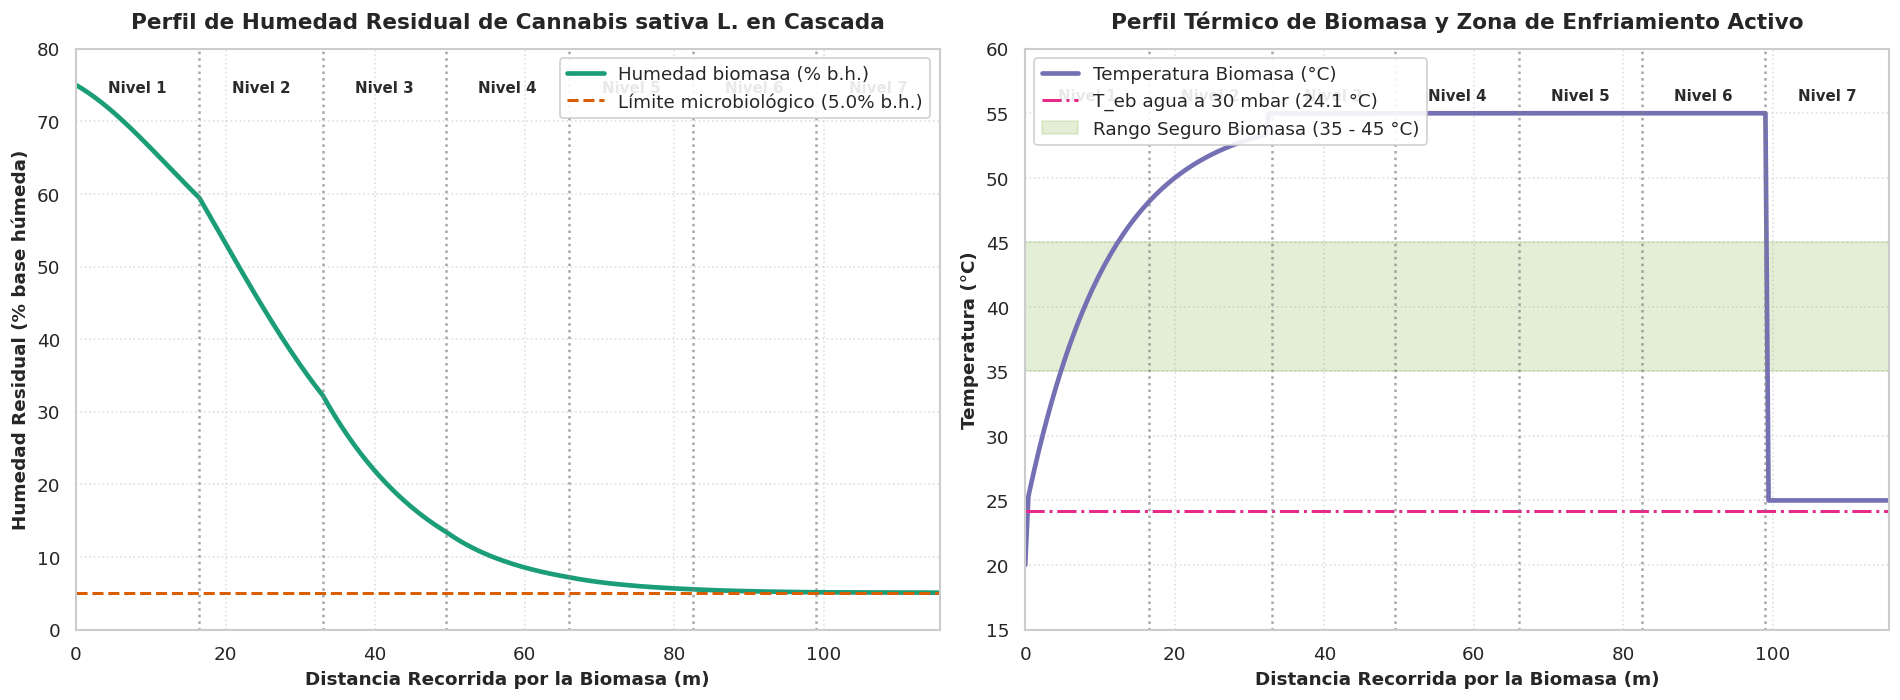

In [23]:
# Creación de la figura de dos paneles con resolución editorial (16x6 pulgadas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=120)

dist = res_sim["distancia_m"]
w_pct = res_sim["w_bh_pct"]
T_b = res_sim["T_biomasa_C"]

# ------------------------------------------------------------------------------
# PANEL IZQUIERDO: Perfil de Humedad Residual vs. Distancia Acumulada
# ------------------------------------------------------------------------------
ax1.plot(dist, w_pct, color='#1b9e77', linewidth=2.8, label='Humedad biomasa (% b.h.)')
ax1.axhline(5.0, color='#d95f02', linestyle='--', linewidth=1.8, label='Límite microbiológico (5.0% b.h.)')

ax1.set_title('Perfil de Humedad Residual de Cannabis sativa L. en Cascada', fontsize=13, fontweight='bold', pad=12)
ax1.set_xlabel('Distancia Recorrida por la Biomasa (m)', fontsize=11, fontweight='semibold')
ax1.set_ylabel('Humedad Residual (% base húmeda)', fontsize=11, fontweight='semibold')
ax1.set_xlim(0, 115.5)
ax1.set_ylim(0, 80)
ax1.grid(True, linestyle=':', alpha=0.6)

# Anotación y líneas verticales para cada nivel
for level in range(1, 8):
    x_mark = level * 16.5
    ax1.axvline(x_mark, color='gray', linestyle=':', alpha=0.7)
    x_center = x_mark - 8.25
    ax1.text(x_center, 74, f'Nivel {level}', fontsize=9, horizontalalignment='center', fontweight='bold', color='#2b2b2b')

ax1.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)

# ------------------------------------------------------------------------------
# PANEL DERECHO: Perfil de Temperatura de Biomasa vs. Distancia Acumulada
# ------------------------------------------------------------------------------
ax2.plot(dist, T_b, color='#7570b3', linewidth=2.8, label='Temperatura Biomasa (°C)')

# Punto de ebullición teórica a 30 mbar invocando termodinamica.py
T_eb_ref = termodinamica.Agua.temperatura_ebullicion(30.0)
ax2.axhline(T_eb_ref, color='#e7298a', linestyle='-.', linewidth=1.8, label=f'T_eb agua a 30 mbar ({T_eb_ref:.1f} °C)')

# Franja de temperatura segura (35 - 45 °C) para evitar descarboxilación y pérdida de terpenos
ax2.axhspan(35.0, 45.0, color='#66a61e', alpha=0.18, label='Rango Seguro Biomasa (35 - 45 °C)')

ax2.set_title('Perfil Térmico de Biomasa y Zona de Enfriamiento Activo', fontsize=13, fontweight='bold', pad=12)
ax2.set_xlabel('Distancia Recorrida por la Biomasa (m)', fontsize=11, fontweight='semibold')
ax2.set_ylabel('Temperatura (°C)', fontsize=11, fontweight='semibold')
ax2.set_xlim(0, 115.5)
ax2.set_ylim(15, 60)
ax2.grid(True, linestyle=':', alpha=0.6)

# Anotación y líneas verticales para cada nivel
for level in range(1, 8):
    x_mark = level * 16.5
    ax2.axvline(x_mark, color='gray', linestyle=':', alpha=0.7)
    x_center = x_mark - 8.25
    ax2.text(x_center, 56, f'Nivel {level}', fontsize=9, horizontalalignment='center', fontweight='bold', color='#2b2b2b')

ax2.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)

plt.tight_layout()
plt.show()